<a href="https://colab.research.google.com/github/krishkishore714-max/Kaggle_projects/blob/main/Titanic_competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Accessing Kaggle Challenge Datasets in Colab

To download datasets from Kaggle challenges, you'll need to use the Kaggle API. This involves a few steps:

1.  **Generate a Kaggle API Key**: Go to your Kaggle account settings (kaggle.com/account), scroll down to the 'API' section, and click 'Create New API Token'. This will download a `kaggle.json` file to your computer.

2.  **Upload `kaggle.json` to Colab Secrets**: In Google Colab, on the left sidebar, click the '🔑' icon (Secrets). Add a new secret named `KAGGLE_USERNAME` and paste your username from the `kaggle.json` file. Then, add another secret named `KAGGLE_KEY` and paste the API key from your `kaggle.json` file.

3.  **Install the Kaggle API client**: Run the following cell to install the necessary library.


In [ ]:
pip install kaggle

4.  **Configure Kaggle API Credentials**: Run the following cell to set up your Kaggle credentials using the secrets you just created. This allows the Kaggle API to authenticate you.


In [ ]:
# Used to securely store your API key
from google.colab import userdata
import os

# Create a .kaggle directory
!mkdir -p ~/.kaggle

# Write the kaggle.json content from Colab secrets
# This ensures the Kaggle API client can find your credentials
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(f'{{"username":"{userdata.get("KAGGLE_USERNAME")}","key":"{userdata.get("KAGGLE_KEY")}"}}')

# Set proper permissions
!chmod 600 ~/.kaggle/kaggle.json

# New Section

5.  **Download the Dataset**: Now you can download the challenge dataset. You'll need the challenge name (e.g., `titanic`). Replace `YOUR_CHALLENGE_NAME` with the actual name of the Kaggle challenge.


In [ ]:
# Replace 'YOUR_CHALLENGE_NAME' with the actual challenge name (e.g., 'titanic')
# You can find the challenge name in the URL, usually after /c/

!kaggle competitions download -c titanic

# After downloading, you might need to unzip the files
# Example for a zip file (adjust as needed if it's not a zip)
# !unzip {CHALLENGE_NAME}.zip -d {CHALLENGE_NAME}

  0% 0.00/34.1k [00:00<?, ?B/s]
100% 34.1k/34.1k [00:00<00:00, 80.1MB/s]


Once downloaded and unzipped, you can then load your `.csv` or other data files into pandas DataFrames as usual, referring to their new path in the Colab environment (e.g., `./YOUR_CHALLENGE_NAME/train.csv`).

In [ ]:
# Unzip the downloaded file
# The kernel state shows that titanic.zip is in /content/
# We will unzip it into a folder also called 'titanic'
!unzip /content/titanic.zip -d titanic

Archive:  /content/titanic.zip
  inflating: titanic/gender_submission.csv  
  inflating: titanic/test.csv        
  inflating: titanic/train.csv       


Let's unzip the downloaded `titanic.zip` file into a new directory named `titanic` to extract its contents.

Now that the files are unzipped, you should be able to load `train.csv` from the `./titanic/` directory.

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('/content/titanic/train.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.shape

(891, 12)

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.dropna(subset =['Embarked'], inplace = True)


In [ ]:
df.Age.fillna(df.Age.mean(), inplace = True)

/tmp/ipython-input-121482172.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Age.fillna(df.Age.mean(), inplace = True)


In [ ]:
df.drop(columns = ['Cabin','Name','Ticket','PassengerId'], inplace = True)

In [ ]:
df.nunique()

,0
Survived,2
Pclass,3
Sex,2
Age,89
SibSp,7
Parch,7
Fare,247
Embarked,3


In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
Le =LabelEncoder()
df.Sex = Le.fit_transform(df.Sex)
df.Embarked = Le.fit_transform(df.Embarked)

In [ ]:
df.Parch.value_counts()

,count
Parch,
0,676
1,118
2,80
5,5
3,5
4,4
6,1


<Axes: >

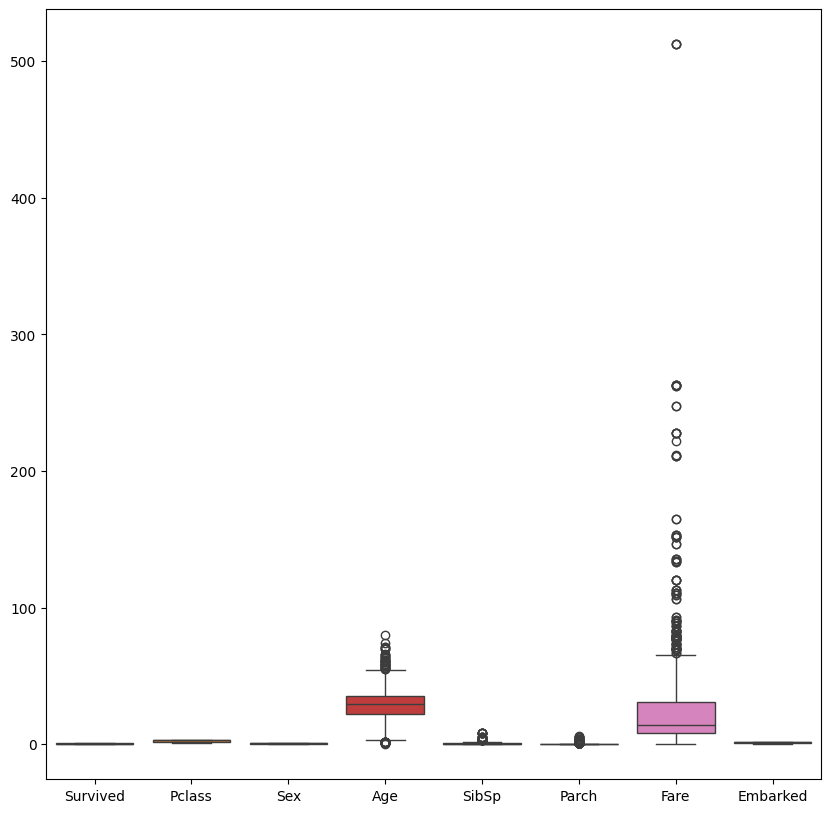

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (10,10))
sns.boxplot(df)

<Axes: xlabel='Age'>

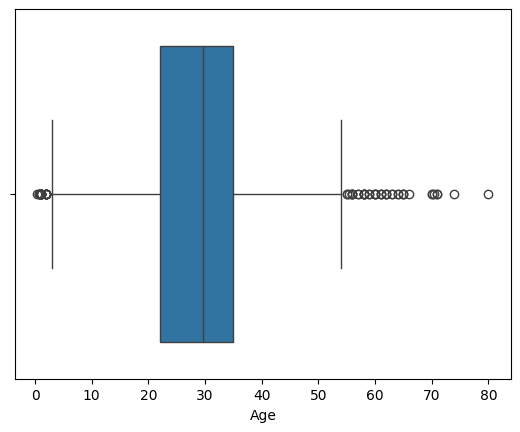

In [ ]:
#outlier removal
sns.boxplot(x = df.Age)

In [ ]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1


In [ ]:
ub = Q3 + 1.5 *IQR
lb = Q1- 1.5 *IQR
df['Age'] = np.where(df['Age']>ub,ub,df['Age'])
df['Age'] = np.where(df['Age']<lb,lb,df['Age'])

In [ ]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
ub = Q3 + 1.5 *IQR
lb = Q1 - 1.5 *IQR
df['Fare'] = np.where(df['Fare']>ub,ub,df['Fare'])
df['Fare'] = np.where(df['Fare']<lb,lb,df['Fare'])

##Feature Extraction and selection

In [ ]:
df['Family'] = df.SibSp + df.Parch

In [ ]:
X = df.drop(columns= 'Survived')
Y = df['Survived']

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scaled = sc.fit_transform(X)


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
x_train , x_valid , y_train , y_valid = train_test_split(X_scaled,Y, test_size = 0.3, random_state=42)





In [ ]:
Y.value_counts()

,count
Survived,
0,549
1,340


**Data Balancing**


In [ ]:
pip install imblearn

In [ ]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
x_train_res, y_train_res = sm.fit_resample(x_train, y_train)
x_valid_res, y_valid_res = sm.fit_resample(x_valid, y_valid)

In [ ]:
train_data = lgb.Dataset(x_train_res, label = y_train_res)
valid_data = lgb.Dataset(x_valid_res, label = y_valid_res)

In [ ]:
parameters = {'objective':'binary', 'metric':'auc', 'is_unbalance':'true','boosting':'gbdt','num_leaves':63,'feature_fraction':0.5,'bagging_fraction':0.5,'bagging_freq':20,'learning_rate': 0.01,'verbose':-1}

In [ ]:
model_lgb = lgb.train(parameters, train_data, valid_sets=[valid_data], num_boost_round=5000, callbacks=[lgb.early_stopping(50)])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[13]	valid_0's auc: 0.884453


In [ ]:
y_valid_pred = model_lgb.predict(x_valid_res)
y_train_pred = model_lgb.predict(x_train_res)

In [ ]:
print("auc_score_valid:", roc_auc_score(y_valid_res, y_valid_pred))
print("auc_score_train:", roc_auc_score(y_train_res, y_train_pred))

auc_score_valid: 0.8844526515830614
auc_score_train: 0.8885755598804856


In [ ]:
# Load the test data
df_test = pd.read_csv('/content/titanic/test.csv')
df_test_passenger_id = df_test['PassengerId']
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### Preprocessing Test Data
We need to apply the exact same preprocessing steps to the test data as we did to the training data.

In [ ]:
# Handle missing values in 'Age' and 'Fare'
df_test['Age'].fillna(df_test['Age'].mean(), inplace=True)
df_test['Fare'].fillna(df_test['Fare'].mean(), inplace=True)

# Apply outlier treatment for Age and Fare using the same bounds as training data
df_test['Age'] = np.where(df_test['Age'] > ub, ub, df_test['Age'])
df_test['Age'] = np.where(df_test['Age'] < lb, lb, df_test['Age'])

Q1_fare = df_test['Fare'].quantile(0.25)
Q3_fare = df_test['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
ub_fare = Q3_fare + 1.5 * IQR_fare
lb_fare = Q1_fare - 1.5 * IQR_fare
df_test['Fare'] = np.where(df_test['Fare'] > ub_fare, ub_fare, df_test['Fare'])
df_test['Fare'] = np.where(df_test['Fare'] < lb_fare, lb_fare, df_test['Fare'])

# Drop columns (excluding PassengerId for now as it's needed for submission)
df_test.drop(columns = ['Cabin','Name','Ticket','PassengerId'], inplace = True)

# Encode categorical features
df_test.Sex = Le.fit_transform(df_test.Sex)
df_test.Embarked = Le.fit_transform(df_test.Embarked)

# Feature engineering: 'Family'
df_test['Family'] = df_test.SibSp + df_test.Parch

df_test.head()

/tmp/ipython-input-2698298769.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['Age'].fillna(df_test['Age'].mean(), inplace=True)
/tmp/ipython-input-2698298769.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family
0,3,1,34.5,0,0,7.8292,1,0
1,3,0,47.0,1,0,7.0000,2,1
2,2,1,62.0,0,0,9.6875,1,0
3,3,1,27.0,0,0,8.6625,2,0
4,3,0,22.0,1,1,12.2875,2,2


### Scale Test Data
Apply the same StandardScaler that was fitted on the training data.

In [ ]:
# Scale the test data using the same scaler fitted on the training data
X_test_scaled = sc.transform(df_test)
X_test_scaled

array([[ 0.82520863,  0.73534203,  0.42976945, ..., -0.79039637,
        -0.67635748, -0.5618044 ],
       [ 0.82520863, -1.35991138,  1.46836231, ..., -0.83103643,
         0.58683958,  0.05785331],
       [-0.37350129,  0.73534203,  2.71467374, ..., -0.69931891,
        -0.67635748, -0.5618044 ],
       ...,
       [ 0.82520863,  0.73534203,  0.76211917, ..., -0.81878364,
         0.58683958, -0.5618044 ],
       [ 0.82520863,  0.73534203,  0.07852486, ..., -0.7795747 ,
         0.58683958, -0.5618044 ],
       [ 0.82520863,  0.73534203,  0.07852486, ..., -0.07830815,
        -1.93955453,  0.67751101]])

### Make Predictions and Create Submission File
Use the trained LightGBM model to make predictions on the preprocessed and scaled test data.

In [ ]:
# Make predictions using the trained LightGBM model
predictions_proba = model_lgb.predict(X_test_scaled)

# Convert probabilities to binary predictions (0 or 1)
predictions_binary = (predictions_proba > 0.5).astype(int)

# Create the submission DataFrame
submission_df = pd.DataFrame({'PassengerId': df_test_passenger_id, 'Survived': predictions_binary})

# Display the first few rows of the submission file
display(submission_df.head())

# Save the submission file to a CSV
submission_df.to_csv('submission.csv', index=False)
print("Submission file created successfully as 'submission.csv'")

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,0


Submission file created successfully as 'submission.csv'
